<div dir="rtl">

# سوال دوم - بخش سوم: سوالات پیاده‌سازی

</div>

In [ ]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 20.0 MB/s eta 0:00:00


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
from datasets import load_dataset
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import copy
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from opacus.utils.batch_memory_manager import BatchMemoryManager
from opacus.accountants.utils import get_noise_multiplier
from opacus.accountants import RDPAccountant
from IPython.display import display
import pandas as pd

In [ ]:
np.random.seed(42)
random.seed(42)

<div dir="rtl">

## زیربخش اول: آماده‌سازی داده‌ها

</div>

<div dir="rtl">

### بارگذاری و بررسی اولیه داده

</div>

In [ ]:
# Load Dataset
dataset = load_dataset("flwrlabs/femnist", split="train")

X_images = np.array([np.array(img) for img in dataset['image']])
y_classes = np.array(dataset['character'])
subjects = np.array(dataset['writer_id'])

README.md:   0%|          | 0.00/6.09k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  201MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/814277 [00:00<?, ? examples/s]

Total Samples: 814277
Total Classes: 62
Total Subjects: 3597
Average Samples per Subject: 226.4
Min Samples per Subject: 18
Max Samples per Subject: 583


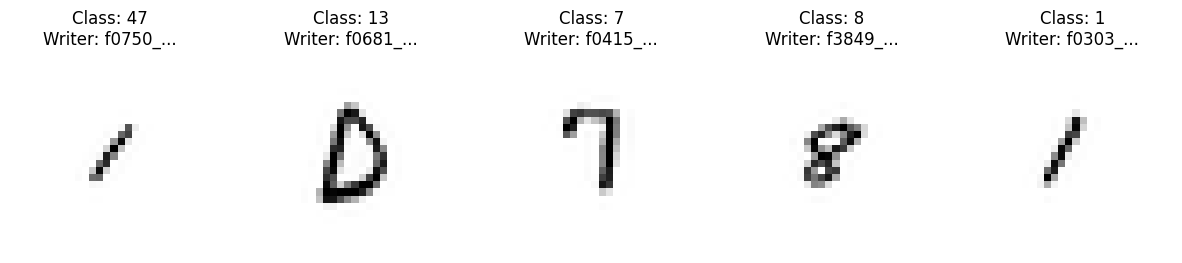

In [ ]:
# Dataset Statistics
total_samples = len(y_classes)
num_classes = len(np.unique(y_classes))
num_subjects = len(np.unique(subjects))

samples_per_subject = list(Counter(subjects).values())
avg_samples = np.mean(samples_per_subject)
min_samples = np.min(samples_per_subject)
max_samples = np.max(samples_per_subject)

print(f"Total Samples: {total_samples}")
print(f"Total Classes: {num_classes}")
print(f"Total Subjects: {num_subjects}")
print(f"Average Samples per Subject: {avg_samples:.1f}")
print(f"Min Samples per Subject: {min_samples}")
print(f"Max Samples per Subject: {max_samples}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = random.randint(0, total_samples - 1)
    ax.imshow(X_images[idx], cmap='gray')
    ax.set_title(f"Class: {y_classes[idx]}\nWriter: {subjects[idx][:6]}...")
    ax.axis('off')
plt.show()

<div dir="rtl">

### تعریف مجموعه‌های Member و Non-Member

</div>

In [ ]:
unique_subjects = np.unique(subjects)
shuffled_subjects = np.random.permutation(unique_subjects)
split_idx = num_subjects // 2

member_subjects = shuffled_subjects[:split_idx]
non_member_subjects = shuffled_subjects[split_idx:]

member_indices = np.where(np.isin(subjects, member_subjects))[0]
non_member_indices = np.where(np.isin(subjects, non_member_subjects))[0]

print(f"Member Subjects: {len(member_subjects)} (Images: {len(member_indices)})")
print(f"Non-Member Subjects: {len(non_member_subjects)} (Images: {len(non_member_indices)})")

Member Subjects: 1798 (Images: 406368)
Non-Member Subjects: 1799 (Images: 407909)


<div dir="rtl">

### ایجاد ساختار Cross-Silo

</div>

In [ ]:
num_silos = 8
silos_data_indices = {i: [] for i in range(num_silos)}
subject_to_silos = {}

for subj in member_subjects:
    n_silos = np.random.randint(1, 4)
    chosen_silos = np.random.choice(range(num_silos), size=n_silos, replace=False)
    subject_to_silos[subj] = chosen_silos

for idx in member_indices:
    subj = subjects[idx]
    chosen_silo = np.random.choice(subject_to_silos[subj])
    silos_data_indices[chosen_silo].append(idx)

<div dir="rtl">

### تحلیل آماری و مصورسازی

</div>

Silo 1: 50163 images (12.3%)
Silo 2: 48133 images (11.8%)
Silo 3: 51479 images (12.7%)
Silo 4: 48022 images (11.8%)
Silo 5: 53228 images (13.1%)
Silo 6: 55273 images (13.6%)
Silo 7: 48799 images (12.0%)
Silo 8: 51271 images (12.6%)

Subjects in exactly 1 silo: 32.0%
Subjects in multiple silos: 68.0%


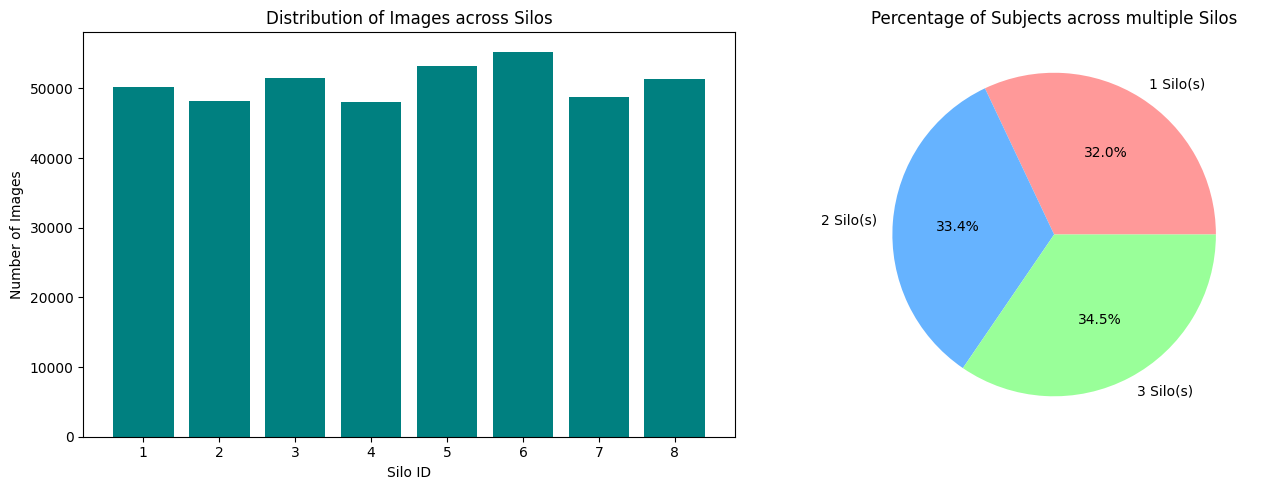

In [ ]:
silo_sizes = [len(indices) for indices in silos_data_indices.values()]
total_member_data = sum(silo_sizes)
silo_shares = [size / total_member_data * 100 for size in silo_sizes]

silos_per_subj_counts = [len(silos) for silos in subject_to_silos.values()]
unique_counts, counts_freq = np.unique(silos_per_subj_counts, return_counts=True)
percent_freq = (counts_freq / len(member_subjects)) * 100

for i in range(num_silos):
    print(f"Silo {i+1}: {silo_sizes[i]} images ({silo_shares[i]:.1f}%)")

print(f"\nSubjects in exactly 1 silo: {percent_freq[0]:.1f}%")
print(f"Subjects in multiple silos: {sum(percent_freq[1:]):.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, num_silos + 1), silo_sizes, color='teal')
ax1.set_xlabel('Silo ID')
ax1.set_ylabel('Number of Images')
ax1.set_title('Distribution of Images across Silos')
ax1.set_xticks(range(1, num_silos + 1))

ax2.pie(percent_freq, labels=[f'{c} Silo(s)' for c in unique_counts],
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
ax2.set_title('Percentage of Subjects across multiple Silos')

plt.tight_layout()
plt.show()

<div dir="rtl">

## زیربخش دوم:‌ آموزش مدل فدرال

</div>

Using device: cuda
Global Test Set Size: 60958 samples

Starting Federated Training (FedAvg):
Round 01/15 | Global Acc: 0.5271 | Global Loss: 1.6408
Round 02/15 | Global Acc: 0.8332 | Global Loss: 0.5227
Round 03/15 | Global Acc: 0.8520 | Global Loss: 0.4556
Round 04/15 | Global Acc: 0.8589 | Global Loss: 0.4272
Round 05/15 | Global Acc: 0.8627 | Global Loss: 0.4126
Round 06/15 | Global Acc: 0.8659 | Global Loss: 0.4031
Round 07/15 | Global Acc: 0.8687 | Global Loss: 0.3966
Round 08/15 | Global Acc: 0.8704 | Global Loss: 0.3912
Round 09/15 | Global Acc: 0.8706 | Global Loss: 0.3880
Round 10/15 | Global Acc: 0.8707 | Global Loss: 0.3868
Round 11/15 | Global Acc: 0.8722 | Global Loss: 0.3860
Round 12/15 | Global Acc: 0.8728 | Global Loss: 0.3843
Round 13/15 | Global Acc: 0.8737 | Global Loss: 0.3855
Round 14/15 | Global Acc: 0.8735 | Global Loss: 0.3848
Round 15/15 | Global Acc: 0.8736 | Global Loss: 0.3876

Final Global Model Accuracy on Member Test Set: 0.8736



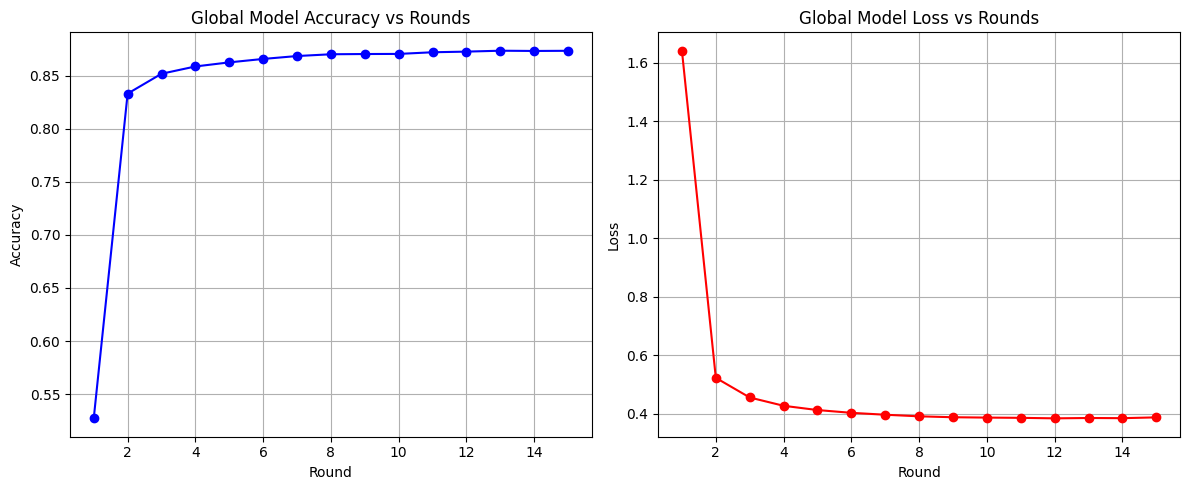

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# hyperparameters
num_rounds = 15
local_epochs = 3
batch_size = 64
learning_rate = 0.001

class FEMNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

silo_train_loaders = []
global_test_X = []
global_test_y = []

for silo_id in range(num_silos):
    idx = silos_data_indices[silo_id]
    np.random.shuffle(idx)

    split_point = int(0.85 * len(idx))
    train_idx = idx[:split_point]
    test_idx = idx[split_point:]

    train_dataset = FEMNISTDataset(X_images[train_idx], y_classes[train_idx])
    silo_train_loaders.append(DataLoader(train_dataset, batch_size=batch_size, shuffle=True))

    global_test_X.extend(X_images[test_idx])
    global_test_y.extend(y_classes[test_idx])

global_test_dataset = FEMNISTDataset(global_test_X, global_test_y)
global_test_loader = DataLoader(global_test_dataset, batch_size=256, shuffle=False)

print(f"Global Test Set Size: {len(global_test_dataset)} samples")

class ClientCNN(nn.Module):
    def __init__(self, num_classes=62):
        super(ClientCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x


global_model = ClientCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()

history = {'accuracy': [], 'loss': []}

saved_global_models = []

# Training
print("\nStarting Federated Training (FedAvg):")
for r in range(num_rounds):
    global_weights = global_model.state_dict()
    silo_weights = []
    silo_sizes = []

    for silo_id, loader in enumerate(silo_train_loaders):
        local_model = ClientCNN(num_classes=num_classes).to(device)
        local_model.load_state_dict(global_weights)
        optimizer = optim.Adam(local_model.parameters(), lr=learning_rate)

        local_model.train()
        for epoch in range(local_epochs):
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = local_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        silo_weights.append(local_model.state_dict())
        silo_sizes.append(len(loader.dataset))

    total_samples = sum(silo_sizes)
    new_global_weights = copy.deepcopy(global_weights)

    for key in new_global_weights.keys():
        new_global_weights[key] = torch.zeros_like(global_weights[key], dtype=torch.float32).to(device)
        for i in range(num_silos):
            weight_factor = silo_sizes[i] / total_samples
            new_global_weights[key] += weight_factor * silo_weights[i][key]

    global_model.load_state_dict(new_global_weights)

    # Evaluation
    global_model.eval()
    correct = 0
    total = 0
    run_loss = 0.0

    with torch.no_grad():
        for images, labels in global_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = global_model(images)
            loss = criterion(outputs, labels)

            run_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = correct / total
    epoch_loss = run_loss / total
    history['accuracy'].append(epoch_acc)
    history['loss'].append(epoch_loss)

    print(f"Round {r+1:02d}/{num_rounds} | Global Acc: {epoch_acc:.4f} | Global Loss: {epoch_loss:.4f}")

    saved_global_models.append(copy.deepcopy(global_model.state_dict()))

print(f"\nFinal Global Model Accuracy on Member Test Set: {history['accuracy'][-1]:.4f}\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_rounds + 1), history['accuracy'], marker='o', color='b')
plt.title('Global Model Accuracy vs Rounds')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_rounds + 1), history['loss'], marker='o', color='r')
plt.title('Global Model Loss vs Rounds')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

<div dir="rtl">

## زیربخش سوم: ارزیابی حملات INFERENCE MEMBERSHIP

</div>

Starting Membership Inference Attacks:
Round 01/15 | Subject Acc: 0.5000 | Record Acc: 0.5140
Round 02/15 | Subject Acc: 0.5000 | Record Acc: 0.5180
Round 03/15 | Subject Acc: 0.5000 | Record Acc: 0.5240
Round 04/15 | Subject Acc: 0.5400 | Record Acc: 0.5100
Round 05/15 | Subject Acc: 0.5800 | Record Acc: 0.5180
Round 06/15 | Subject Acc: 0.6000 | Record Acc: 0.5180
Round 07/15 | Subject Acc: 0.6400 | Record Acc: 0.5160
Round 08/15 | Subject Acc: 0.6100 | Record Acc: 0.5200
Round 09/15 | Subject Acc: 0.6600 | Record Acc: 0.5180
Round 10/15 | Subject Acc: 0.6200 | Record Acc: 0.5200
Round 11/15 | Subject Acc: 0.6900 | Record Acc: 0.5220
Round 12/15 | Subject Acc: 0.6400 | Record Acc: 0.5160
Round 13/15 | Subject Acc: 0.6500 | Record Acc: 0.5100
Round 14/15 | Subject Acc: 0.6400 | Record Acc: 0.5100
Round 15/15 | Subject Acc: 0.6500 | Record Acc: 0.5140

--- Subject-Level Attack (Loss-Across-Rounds) ---
Accuracy:  0.6500
Precision: 0.6271
Recall:    0.7400
F1-Score:  0.6789

--- Record-L

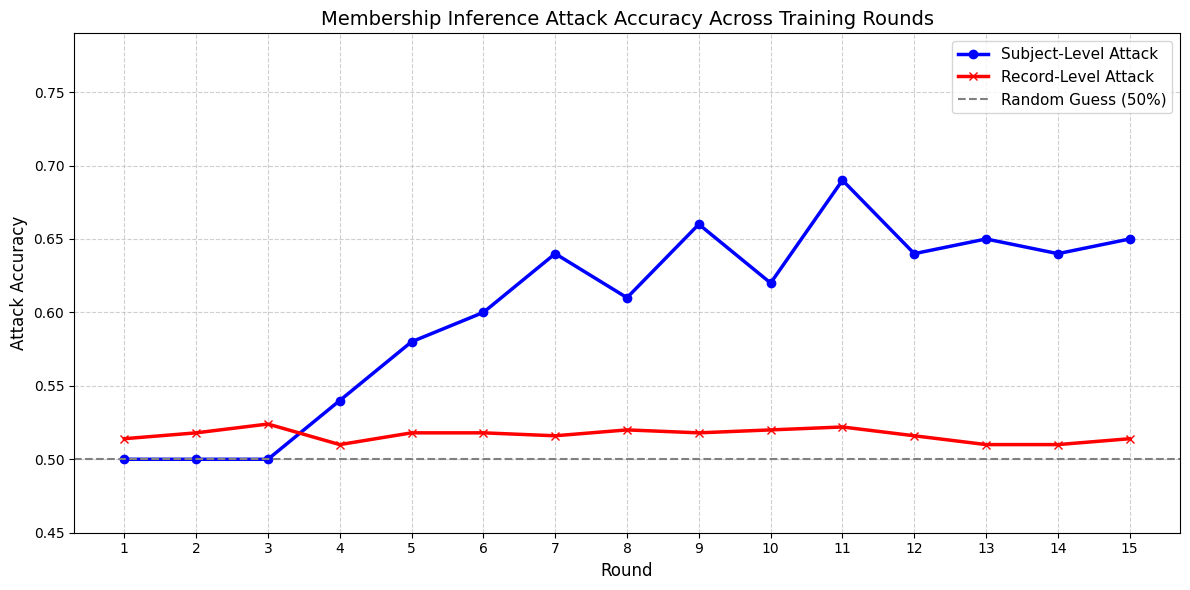

In [ ]:
def find_subject_data(subject_id):
    idx = np.where(subjects == subject_id)[0]
    return X_images[idx], y_classes[idx]

def calculate_loss(model_state, X, y):
    temp_model = ClientCNN(num_classes=num_classes).to(device)
    temp_model.load_state_dict(model_state)
    temp_model.eval()

    dataset = FEMNISTDataset(X, y)
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    criterion = nn.CrossEntropyLoss(reduction='sum')

    total_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = temp_model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(X)

np.random.seed(42)

num_eval_subjects = min(50, len(member_subjects), len(non_member_subjects))
eval_members = np.random.choice(member_subjects, num_eval_subjects, replace=False)
eval_non_members = np.random.choice(non_member_subjects, num_eval_subjects, replace=False)

eval_member_idx = np.random.choice(member_indices, 500, replace=False)
eval_non_member_idx = np.random.choice(non_member_indices, 500, replace=False)

round_subject_acc, round_subject_prec, round_subject_rec, round_subject_f1 = [], [], [], []
round_record_acc, round_record_prec, round_record_rec, round_record_f1 = [], [], [], []

print("Starting Membership Inference Attacks:")

for r in range(len(saved_global_models)):
    current_model_state = saved_global_models[r]

    # Record-Level Attack
    r_scores = []
    r_labels = []

    for idx in eval_member_idx:
        X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
        loss = calculate_loss(current_model_state, X_rec, y_rec)
        r_scores.append(loss)
        r_labels.append(1)

    for idx in eval_non_member_idx:
        X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
        loss = calculate_loss(current_model_state, X_rec, y_rec)
        r_scores.append(loss)
        r_labels.append(0)

    r_thresh = np.median(r_scores)
    r_preds = [1 if s < r_thresh else 0 for s in r_scores]

    round_record_acc.append(accuracy_score(r_labels, r_preds))
    round_record_prec.append(precision_score(r_labels, r_preds, zero_division=0))
    round_record_rec.append(recall_score(r_labels, r_preds, zero_division=0))
    round_record_f1.append(f1_score(r_labels, r_preds, zero_division=0))

    # Subject-Level Attack
    s_scores = []
    s_labels = []

    for subj in eval_members:
        X_subj, y_subj = find_subject_data(subj)
        losses = [calculate_loss(saved_global_models[i], X_subj, y_subj) for i in range(r + 1)]
        decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
        s_scores.append(decreases_count)
        s_labels.append(1)

    for subj in eval_non_members:
        X_subj, y_subj = find_subject_data(subj)
        losses = [calculate_loss(saved_global_models[i], X_subj, y_subj) for i in range(r + 1)]
        decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
        s_scores.append(decreases_count)
        s_labels.append(0)

    s_thresh = np.median(s_scores)
    s_preds = [1 if s >= s_thresh else 0 for s in s_scores]

    round_subject_acc.append(accuracy_score(s_labels, s_preds))
    round_subject_prec.append(precision_score(s_labels, s_preds, zero_division=0))
    round_subject_rec.append(recall_score(s_labels, s_preds, zero_division=0))
    round_subject_f1.append(f1_score(s_labels, s_preds, zero_division=0))

    print(f"Round {r+1:02d}/{len(saved_global_models)} | Subject Acc: {round_subject_acc[-1]:.4f} | Record Acc: {round_record_acc[-1]:.4f}")

print("\n--- Subject-Level Attack (Loss-Across-Rounds) ---")
print(f"Accuracy:  {round_subject_acc[-1]:.4f}")
print(f"Precision: {round_subject_prec[-1]:.4f}")
print(f"Recall:    {round_subject_rec[-1]:.4f}")
print(f"F1-Score:  {round_subject_f1[-1]:.4f}\n")

print("--- Record-Level Attack (Baseline) ---")
print(f"Accuracy:  {round_record_acc[-1]:.4f}")
print(f"Precision: {round_record_prec[-1]:.4f}")
print(f"Recall:    {round_record_rec[-1]:.4f}")
print(f"F1-Score:  {round_record_f1[-1]:.4f}")
print()


plt.figure(figsize=(12, 6))

plt.plot(range(1, len(saved_global_models) + 1), round_subject_acc, marker='o', label='Subject-Level Attack', color='blue', linewidth=2.5)
plt.plot(range(1, len(saved_global_models) + 1), round_record_acc, marker='x', label='Record-Level Attack', color='red', linewidth=2.5)

plt.title('Membership Inference Attack Accuracy Across Training Rounds', fontsize=14)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Attack Accuracy', fontsize=12)
plt.axhline(y=0.5, color='gray', linestyle='--', label='Random Guess (50%)')
plt.xticks(range(1, len(saved_global_models) + 1))
plt.ylim([0.45, max(max(round_subject_acc), max(round_record_acc)) + 0.1])
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<div dir="rtl">

## زیربخش چهارم: دفاع مبتنی بر DIFFERENTIAL PRIVACY

</div>

<div dir="rtl">

###  ۴.۱- دفاع پایه (DP-SGD / Record-Level DP)

</div>

In [20]:
target_epsilon = 4.0
target_delta = 1e-5
clipping_norm = 1.0
fast_local_epochs = 1

global_model_dp_record = ClientCNN(num_classes=num_classes).to(device)
global_model_dp_record = ModuleValidator.fix(global_model_dp_record)

saved_global_models_dp_record = []
round_epsilons = []

print("Starting Federated Training with Record-Level DP:")

for r in range(num_rounds):
    global_weights = global_model_dp_record.state_dict()
    silo_weights = []
    silo_sizes = []
    round_eps_temp = []

    for silo_id, loader in enumerate(silo_train_loaders):
        local_model = ClientCNN(num_classes=num_classes).to(device)
        local_model.load_state_dict(global_weights)
        optimizer = optim.Adam(local_model.parameters(), lr=learning_rate)

        privacy_engine = PrivacyEngine()
        local_model, optimizer, dp_loader = privacy_engine.make_private_with_epsilon(
            module=local_model,
            optimizer=optimizer,
            data_loader=loader,
            epochs=fast_local_epochs,
            target_epsilon=target_epsilon / num_rounds,
            target_delta=target_delta,
            max_grad_norm=clipping_norm,
        )

        local_model.train()
        for epoch in range(fast_local_epochs):
            with BatchMemoryManager(data_loader=dp_loader, max_physical_batch_size=128, optimizer=optimizer) as memory_safe_data_loader:
                for images, labels in memory_safe_data_loader:
                    images, labels = images.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = local_model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

        clean_state_dict = {k.replace("_module.", ""): v for k, v in local_model.state_dict().items()}
        silo_weights.append(clean_state_dict)
        silo_sizes.append(len(loader.dataset))
        round_eps_temp.append(privacy_engine.get_epsilon(target_delta))

    actual_sigma = optimizer.noise_multiplier

    total_samples = sum(silo_sizes)
    new_global_weights = copy.deepcopy(global_weights)

    for key in new_global_weights.keys():
        new_global_weights[key] = torch.zeros_like(global_weights[key], dtype=torch.float32).to(device)
        for i in range(num_silos):
            weight_factor = silo_sizes[i] / total_samples
            new_global_weights[key] += weight_factor * silo_weights[i][key]

    global_model_dp_record.load_state_dict(new_global_weights)
    saved_global_models_dp_record.append(copy.deepcopy(global_model_dp_record.state_dict()))

    avg_epsilon = sum(round_eps_temp) / len(round_eps_temp)
    round_epsilons.append(avg_epsilon)

    cumulative_epsilon = sum(round_epsilons)
    print(f"Round {r+1:02d}/{num_rounds} | Cumulative Epsilon: {cumulative_epsilon:.4f}")


print("\n--- Report parameters for Record-Level DP ---")
print(f"Target Epsilon (ε): {target_epsilon}")
print(f"Target Delta (δ): {target_delta}")
print(f"Clipping Norm: {clipping_norm}")
print(f"Noise Multiplier (σ): {actual_sigma:.4f}")

global_model_dp_record.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in global_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = global_model_dp_record(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Global Model Accuracy (Utility): {correct / total:.4f}")

final_dp_model = saved_global_models_dp_record[-1]

# Record-Level Attack
r_scores, r_labels = [], []
for idx in eval_member_idx:
    X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
    r_scores.append(calculate_loss(final_dp_model, X_rec, y_rec))
    r_labels.append(1)
for idx in eval_non_member_idx:
    X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
    r_scores.append(calculate_loss(final_dp_model, X_rec, y_rec))
    r_labels.append(0)

r_thresh = np.median(r_scores)
r_preds = [1 if s < r_thresh else 0 for s in r_scores]

# Subject-Level Attack
s_scores, s_labels = [], []

for subj in eval_members:
    X_subj, y_subj = find_subject_data(subj)
    losses = [calculate_loss(saved_global_models_dp_record[i], X_subj, y_subj) for i in range(len(saved_global_models_dp_record))]
    decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
    s_scores.append(decreases_count)
    s_labels.append(1)

for subj in eval_non_members:
    X_subj, y_subj = find_subject_data(subj)
    losses = [calculate_loss(saved_global_models_dp_record[i], X_subj, y_subj) for i in range(len(saved_global_models_dp_record))]
    decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
    s_scores.append(decreases_count)
    s_labels.append(0)

s_thresh = np.median(s_scores)
s_preds = [1 if s >= s_thresh else 0 for s in s_scores]

print("\n--- Attack Results on Record-Level DP Model ---")
print(f"Record-Level Attack  -> Accuracy: {accuracy_score(r_labels, r_preds):.4f} | F1-Score: {f1_score(r_labels, r_preds, zero_division=0):.4f}")
print(f"Subject-Level Attack -> Accuracy: {accuracy_score(s_labels, s_preds):.4f} | F1-Score: {f1_score(s_labels, s_preds, zero_division=0):.4f}")

Starting Federated Training with Record-Level DP:
Round 01/15 | Cumulative Epsilon: 0.2613
Round 02/15 | Cumulative Epsilon: 0.5226
Round 03/15 | Cumulative Epsilon: 0.7838
Round 04/15 | Cumulative Epsilon: 1.0451
Round 05/15 | Cumulative Epsilon: 1.3064
Round 06/15 | Cumulative Epsilon: 1.5677
Round 07/15 | Cumulative Epsilon: 1.8290
Round 08/15 | Cumulative Epsilon: 2.0903
Round 09/15 | Cumulative Epsilon: 2.3515
Round 10/15 | Cumulative Epsilon: 2.6128
Round 11/15 | Cumulative Epsilon: 2.8741
Round 12/15 | Cumulative Epsilon: 3.1354
Round 13/15 | Cumulative Epsilon: 3.3967
Round 14/15 | Cumulative Epsilon: 3.6580
Round 15/15 | Cumulative Epsilon: 3.9192

--- Report parameters for Record-Level DP ---
Target Epsilon (ε): 4.0
Target Delta (δ): 1e-05
Clipping Norm: 1.0
Noise Multiplier (σ): 0.9082
Global Model Accuracy (Utility): 0.5079

--- Attack Results on Record-Level DP Model ---
Record-Level Attack  -> Accuracy: 0.5240 | F1-Score: 0.5240
Subject-Level Attack -> Accuracy: 0.4800 | 

<div dir="rtl">

###  ۴.۲- دفاع پیشرفته (Subject-Level DP)

</div>

In [21]:
target_epsilon_subj = 4.0
target_delta_subj = 1e-5
server_clipping_norm = 1.5
fast_local_epochs = 1

sigma_server = get_noise_multiplier(
    target_epsilon=target_epsilon_subj,
    target_delta=target_delta_subj,
    sample_rate=1.0,
    epochs=num_rounds
)

global_model_dp_subj = ClientCNN(num_classes=num_classes).to(device)
saved_global_models_dp_subj = []

accountant = RDPAccountant()
print("Starting Federated Training with Subject-Level DP:")

for r in range(num_rounds):
    global_weights = global_model_dp_subj.state_dict()
    silo_deltas = []

    for silo_id, loader in enumerate(silo_train_loaders):
        local_model = ClientCNN(num_classes=num_classes).to(device)
        local_model.load_state_dict(global_weights)
        optimizer = optim.Adam(local_model.parameters(), lr=learning_rate)

        local_model.train()
        for epoch in range(fast_local_epochs):
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = local_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        local_weights = local_model.state_dict()
        delta_w = {k: local_weights[k] - global_weights[k] for k in global_weights.keys()}
        silo_deltas.append(delta_w)

    new_global_weights = copy.deepcopy(global_weights)

    for key in new_global_weights.keys():
        clipped_deltas = []
        for delta_w in silo_deltas:
            update_tensor = delta_w[key]
            l2_norm = torch.norm(update_tensor, p=2)
            clip_factor = max(1.0, (l2_norm / server_clipping_norm).item())
            clipped_deltas.append(update_tensor / clip_factor)

        avg_delta = torch.stack(clipped_deltas).mean(dim=0)
        noise_std = (sigma_server * server_clipping_norm) / num_silos
        noise = torch.randn_like(avg_delta) * noise_std
        dp_delta = avg_delta + noise

        new_global_weights[key] += dp_delta

    global_model_dp_subj.load_state_dict(new_global_weights)
    saved_global_models_dp_subj.append(copy.deepcopy(global_model_dp_subj.state_dict()))

    accountant.step(noise_multiplier=sigma_server, sample_rate=1.0)
    cumulative_epsilon = accountant.get_epsilon(delta=target_delta_subj)
    print(f"Round {r+1:02d}/{num_rounds} | Cumulative Epsilon: {cumulative_epsilon:.4f}")

print("\n--- Report parameters for Subject-Level DP ---")
print(f"Target Epsilon (ε): {target_epsilon_subj}")
print(f"Target Delta (δ): {target_delta_subj}")
print(f"Server Clipping Norm: {server_clipping_norm}")
print(f"Calculated Noise Multiplier (σ): {sigma_server:.4f}")

global_model_dp_subj.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in global_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = global_model_dp_subj(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Global Model Accuracy (Utility): {correct / total:.4f}")

final_subj_dp_model = saved_global_models_dp_subj[-1]

# Record-Level Attack
r_scores, r_labels = [], []
for idx in eval_member_idx:
    X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
    r_scores.append(calculate_loss(final_subj_dp_model, X_rec, y_rec))
    r_labels.append(1)
for idx in eval_non_member_idx:
    X_rec, y_rec = X_images[idx:idx+1], y_classes[idx:idx+1]
    r_scores.append(calculate_loss(final_subj_dp_model, X_rec, y_rec))
    r_labels.append(0)

r_thresh = np.median(r_scores)
r_preds = [1 if s < r_thresh else 0 for s in r_scores]

# Subject-Level Attack
s_scores, s_labels = [], []

for subj in eval_members:
    X_subj, y_subj = find_subject_data(subj)
    losses = [calculate_loss(saved_global_models_dp_subj[i], X_subj, y_subj) for i in range(len(saved_global_models_dp_subj))]
    decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
    s_scores.append(decreases_count)
    s_labels.append(1)

for subj in eval_non_members:
    X_subj, y_subj = find_subject_data(subj)
    losses = [calculate_loss(saved_global_models_dp_subj[i], X_subj, y_subj) for i in range(len(saved_global_models_dp_subj))]
    decreases_count = sum(1 for i in range(1, len(losses)) if losses[i] < losses[i-1])
    s_scores.append(decreases_count)
    s_labels.append(0)

s_thresh = np.median(s_scores)
s_preds = [1 if s >= s_thresh else 0 for s in s_scores]

print("\n--- Attack Results on Subject-Level DP Model ---")
print(f"Record-Level Attack  -> Accuracy: {accuracy_score(r_labels, r_preds):.4f} | F1-Score: {f1_score(r_labels, r_preds, zero_division=0):.4f}")
print(f"Subject-Level Attack -> Accuracy: {accuracy_score(s_labels, s_preds):.4f} | F1-Score: {f1_score(s_labels, s_preds, zero_division=0):.4f}")

Starting Federated Training with Subject-Level DP:
Round 01/15 | Cumulative Epsilon: 0.8925
Round 02/15 | Cumulative Epsilon: 1.3023
Round 03/15 | Cumulative Epsilon: 1.6257
Round 04/15 | Cumulative Epsilon: 1.9048
Round 05/15 | Cumulative Epsilon: 2.1550
Round 06/15 | Cumulative Epsilon: 2.3845
Round 07/15 | Cumulative Epsilon: 2.5984
Round 08/15 | Cumulative Epsilon: 2.7996
Round 09/15 | Cumulative Epsilon: 2.9906
Round 10/15 | Cumulative Epsilon: 3.1730
Round 11/15 | Cumulative Epsilon: 3.3480
Round 12/15 | Cumulative Epsilon: 3.5166
Round 13/15 | Cumulative Epsilon: 3.6796
Round 14/15 | Cumulative Epsilon: 3.8375
Round 15/15 | Cumulative Epsilon: 3.9909

--- Report parameters for Subject-Level DP ---
Target Epsilon (ε): 4.0
Target Delta (δ): 1e-05
Server Clipping Norm: 1.5
Calculated Noise Multiplier (σ): 4.4922
Global Model Accuracy (Utility): 0.0181

--- Attack Results on Subject-Level DP Model ---
Record-Level Attack  -> Accuracy: 0.5000 | F1-Score: 0.5000
Subject-Level Attack -

<div dir="rtl">

###  ۴.۳- آزمایش حساسیت

</div>

In [22]:
base_rounds = 15
base_clip_norm = 1.0
base_sigma = 0.90
target_delta = 1e-5

def simulate_theoretical_epsilon(exp_name, rounds, clip_norm, sigma):
    accountant = RDPAccountant()
    representative_loader = silo_train_loaders[0]
    dataset_size = len(representative_loader.dataset)
    batch_size = representative_loader.batch_size
    sample_rate = batch_size / dataset_size
    steps = len(representative_loader)

    for r in range(rounds):
        for _ in range(steps):
            accountant.step(noise_multiplier=sigma, sample_rate=sample_rate)

    final_epsilon = accountant.get_epsilon(delta=target_delta)

    print(f"--- {exp_name} ---")
    print(f"Parameters: Rounds={rounds} | Clipping Norm={clip_norm} | Sigma (Noise)={sigma}")
    print(f"Final Calculated Epsilon (ε): {final_epsilon:.4f}\n")


simulate_theoretical_epsilon("Baseline (Section 4.1)", base_rounds, base_clip_norm, base_sigma)

simulate_theoretical_epsilon("Experiment 1: Double Sigma", base_rounds, base_clip_norm, base_sigma * 2)

simulate_theoretical_epsilon("Experiment 2: Halve Clipping Norm", base_rounds, base_clip_norm / 2, base_sigma)

simulate_theoretical_epsilon("Experiment 3: Double Rounds", base_rounds * 2, base_clip_norm, base_sigma)

--- Baseline (Section 4.1) ---
Parameters: Rounds=15 | Clipping Norm=1.0 | Sigma (Noise)=0.9
Final Calculated Epsilon (ε): 1.2588

--- Experiment 1: Double Sigma ---
Parameters: Rounds=15 | Clipping Norm=1.0 | Sigma (Noise)=1.8
Final Calculated Epsilon (ε): 0.3419

--- Experiment 2: Halve Clipping Norm ---
Parameters: Rounds=15 | Clipping Norm=0.5 | Sigma (Noise)=0.9
Final Calculated Epsilon (ε): 1.2588

--- Experiment 3: Double Rounds ---
Parameters: Rounds=30 | Clipping Norm=1.0 | Sigma (Noise)=0.9
Final Calculated Epsilon (ε): 1.5495



<div dir="rtl">

###  ۴.۴- مقایسه و تحلیل Trade-off

</div>

In [28]:
data = {
    "Defense Type": [
        "Baseline (No DP)",
        "Record-Level DP",
        "Subject-Level DP"
    ],
    "Epsilon Budget": [
        "Infinity",
        "4.00",
        "4.00"
    ],
    "Noise Multiplier": [
        "0.0000",
        "0.9082",
        "4.4922"
    ],
    "Model Utility (Acc)": [
        "0.8736",
        "0.5079",
        "0.0181"
    ],
    "Record-Level Attack Acc": [
        "0.5140",
        "0.5240",
        "0.5000"
    ],
    "Subject-Level Attack Acc": [
        "0.6500",
        "0.4800",
        "0.4700"
    ]
}

df_summary = pd.DataFrame(data)
df_summary.set_index("Defense Type", inplace=True)

print("--- Summary & Comparison of Defenses ---\n")

display(df_summary)

--- Summary & Comparison of Defenses ---



,Epsilon Budget,Noise Multiplier,Model Utility (Acc),Record-Level Attack Acc,Subject-Level Attack Acc
Defense Type,,,,,
Baseline (No DP),Infinity,0.0000,0.8736,0.5140,0.6500
Record-Level DP,4.00,0.9082,0.5079,0.5240,0.4800
Subject-Level DP,4.00,4.4922,0.0181,0.5000,0.4700
